Labsheet-5 Uday saini (cu24250246) B.Tech cse Sec-C Roll No :61

In [ ]:
# Install required libraries
!pip install -q opencv-contrib-python scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure

from google.colab import files

In [ ]:
uploaded = files.upload()

image_names = list(uploaded.keys())

print("Uploaded images:")
for name in image_names:
    print(name)


Saving fd89cce0b421b6b4d37959ffc4422efc.jpg to fd89cce0b421b6b4d37959ffc4422efc (1).jpg
Saving imagebbs.jfif to imagebbs (1).jfif
Uploaded images:
fd89cce0b421b6b4d37959ffc4422efc (1).jpg
imagebbs (1).jfif


Image 1 size: (414, 736, 3)
Image 2 size: (619, 494, 3)


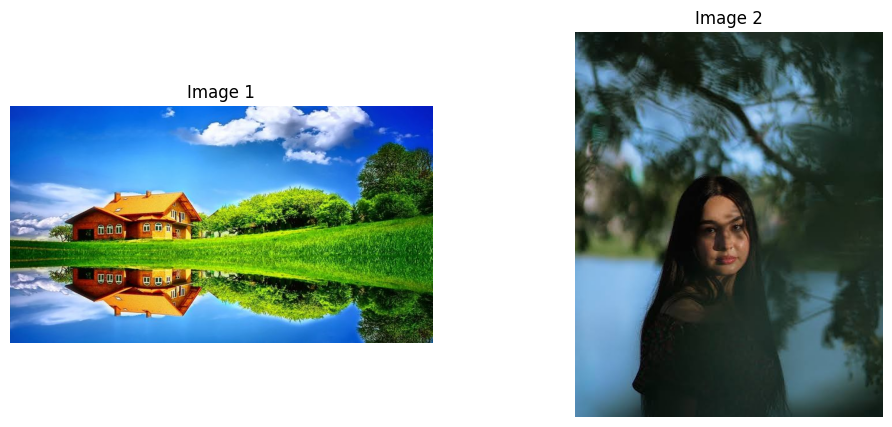

In [ ]:
# Make sure at least two images are uploaded
if len(image_names) < 2:
    raise ValueError("Please upload at least TWO similar images.")

# Read images
img1 = cv2.imread(image_names[0])
img2 = cv2.imread(image_names[1])

# Check images
if img1 is None or img2 is None:
    raise ValueError("Could not read one or both images.")

# Convert BGR to RGB for displaying
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

print("Image 1 size:", img1.shape)
print("Image 2 size:", img2.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1_rgb)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title("Image 2")
plt.axis("off")

plt.show()


In [ ]:
# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and calculate descriptors
keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

print("Number of SIFT keypoints in Image 1:", len(keypoints1))
print("Number of SIFT keypoints in Image 2:", len(keypoints2))

print("Descriptor shape - Image 1:", descriptors1.shape)
print("Descriptor shape - Image 2:", descriptors2.shape)

Number of SIFT keypoints in Image 1: 2186
Number of SIFT keypoints in Image 2: 460
Descriptor shape - Image 1: (2186, 128)
Descriptor shape - Image 2: (460, 128)


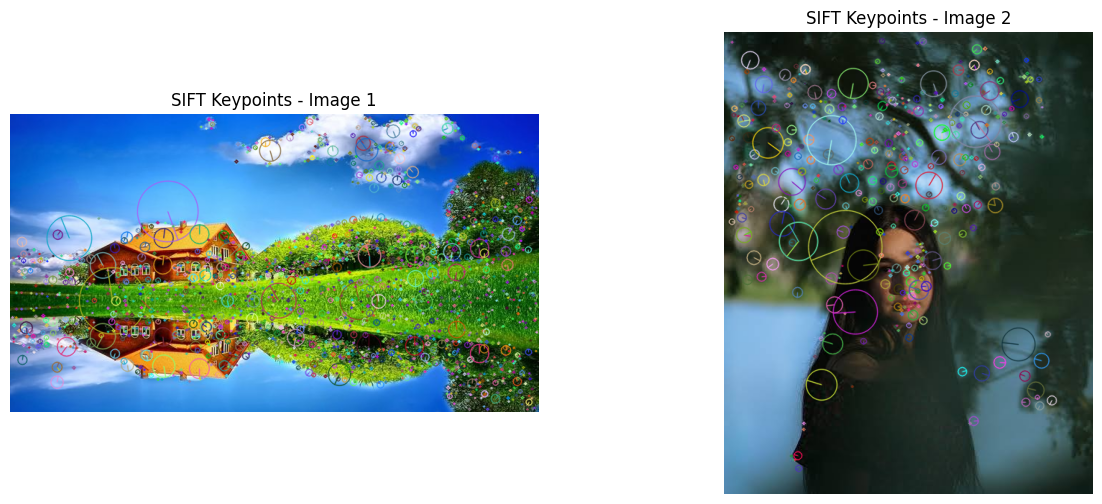

In [ ]:
# Draw keypoints
sift_img1 = cv2.drawKeypoints(
    img1_rgb,
    keypoints1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

sift_img2 = cv2.drawKeypoints(
    img2_rgb,
    keypoints2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(sift_img1)
plt.title("SIFT Keypoints - Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sift_img2)
plt.title("SIFT Keypoints - Image 2")
plt.axis("off")

plt.show()


PART-B HOG Feature Extraction

In [ ]:
# Resize image for HOG
hog_size = (256, 256)

gray1_resized = cv2.resize(gray1, hog_size)
gray2_resized = cv2.resize(gray2, hog_size)

# HOG parameters
orientations = 9
pixels_per_cell = (8, 8)
cells_per_block = (2, 2)

# HOG for Image 1
features1, hog_image1 = hog(
    gray1_resized,
    orientations=orientations,
    pixels_per_cell=pixels_per_cell,
    cells_per_block=cells_per_block,
    block_norm='L2-Hys',
    visualize=True
)

# HOG for Image 2
features2, hog_image2 = hog(
    gray2_resized,
    orientations=orientations,
    pixels_per_cell=pixels_per_cell,
    cells_per_block=cells_per_block,
    block_norm='L2-Hys',
    visualize=True
)

print("HOG feature length - Image 1:", len(features1))
print("HOG feature length - Image 2:", len(features2))

HOG feature length - Image 1: 34596
HOG feature length - Image 2: 34596


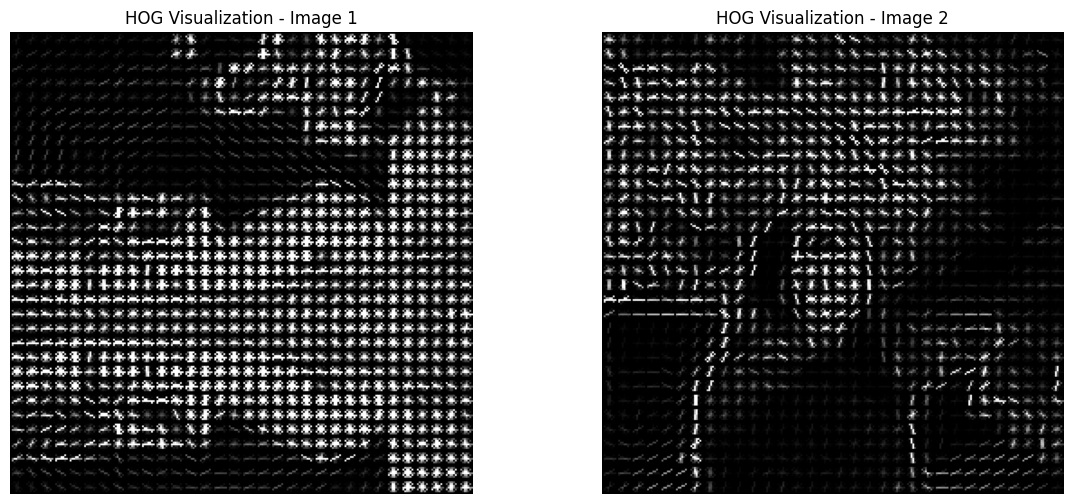

In [ ]:
# Improve HOG visualization
hog_image1 = exposure.rescale_intensity(
    hog_image1,
    in_range=(0, 10)
)

hog_image2 = exposure.rescale_intensity(
    hog_image2,
    in_range=(0, 10)
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(hog_image1, cmap='gray')
plt.title("HOG Visualization - Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image2, cmap='gray')
plt.title("HOG Visualization - Image 2")
plt.axis("off")

plt.show()

In [ ]:
print("=" * 50)
print("FEATURE EXTRACTION COMPARISON")
print("=" * 50)

print("\nSIFT")
print("Image 1 keypoints:", len(keypoints1))
print("Image 2 keypoints:", len(keypoints2))
print("Image 1 descriptor size:", descriptors1.shape)
print("Image 2 descriptor size:", descriptors2.shape)

print("\nHOG")
print("Image 1 feature length:", len(features1))
print("Image 2 feature length:", len(features2))

print("\nHOG Parameters")
print("Orientation bins:", orientations)
print("Pixels per cell:", pixels_per_cell)
print("Cells per block:", cells_per_block)

FEATURE EXTRACTION COMPARISON

SIFT
Image 1 keypoints: 2186
Image 2 keypoints: 460
Image 1 descriptor size: (2186, 128)
Image 2 descriptor size: (460, 128)

HOG
Image 1 feature length: 34596
Image 2 feature length: 34596

HOG Parameters
Orientation bins: 9
Pixels per cell: (8, 8)
Cells per block: (2, 2)


In [ ]:
# Create Brute-Force matcher
bf = cv2.BFMatcher()

# KNN matching
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply Lowe's ratio test
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Total matches:", len(matches))
print("Good matches:", len(good_matches))

Total matches: 2186
Good matches: 13


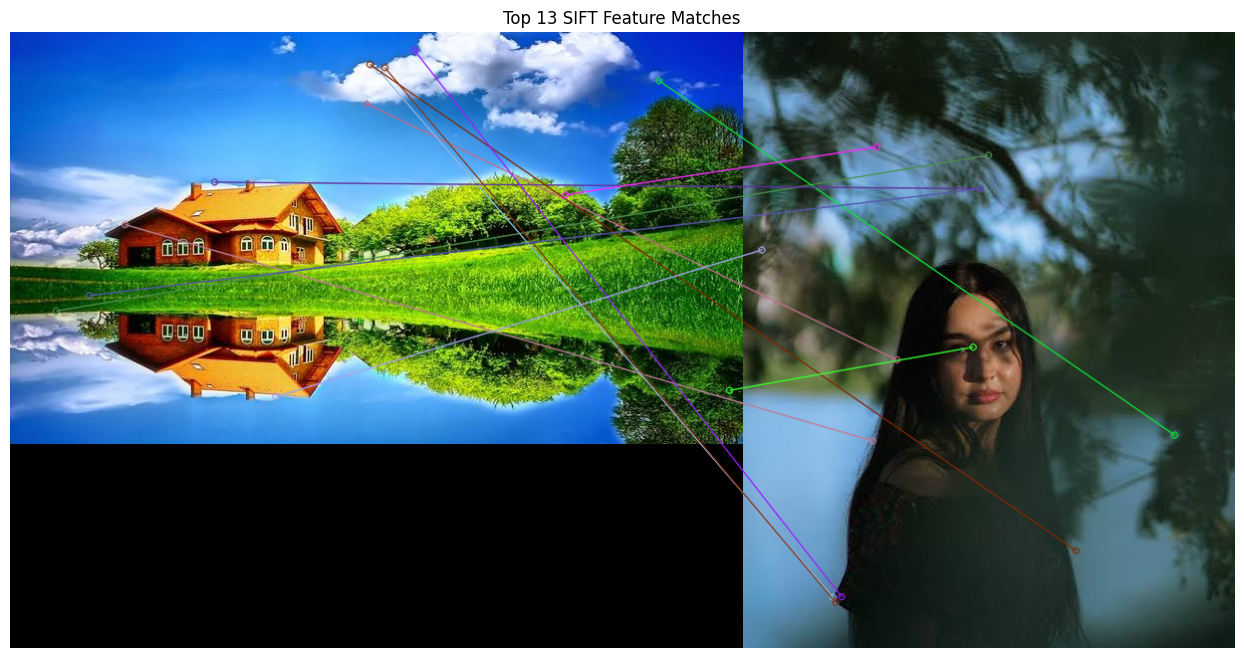

In [ ]:
# Sort good matches by distance
good_matches = sorted(good_matches, key=lambda x: x.distance)

# Display top matches
num_matches = min(30, len(good_matches))

matched_image = cv2.drawMatches(
    img1_rgb,
    keypoints1,
    img2_rgb,
    keypoints2,
    good_matches[:num_matches],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(18, 8))
plt.imshow(matched_image)
plt.title(f"Top {num_matches} SIFT Feature Matches")
plt.axis("off")
plt.show()

In [ ]:
# Calculate Euclidean distance between HOG descriptors
hog_distance = np.linalg.norm(features1 - features2)

print("HOG Euclidean Distance:", hog_distance)

if hog_distance < 10:
    print("Result: Images are highly similar.")
elif hog_distance < 30:
    print("Result: Images have moderate similarity.")
else:
    print("Result: Images are relatively different.")



HOG Euclidean Distance: 26.864093383179206
Result: Images have moderate similarity.


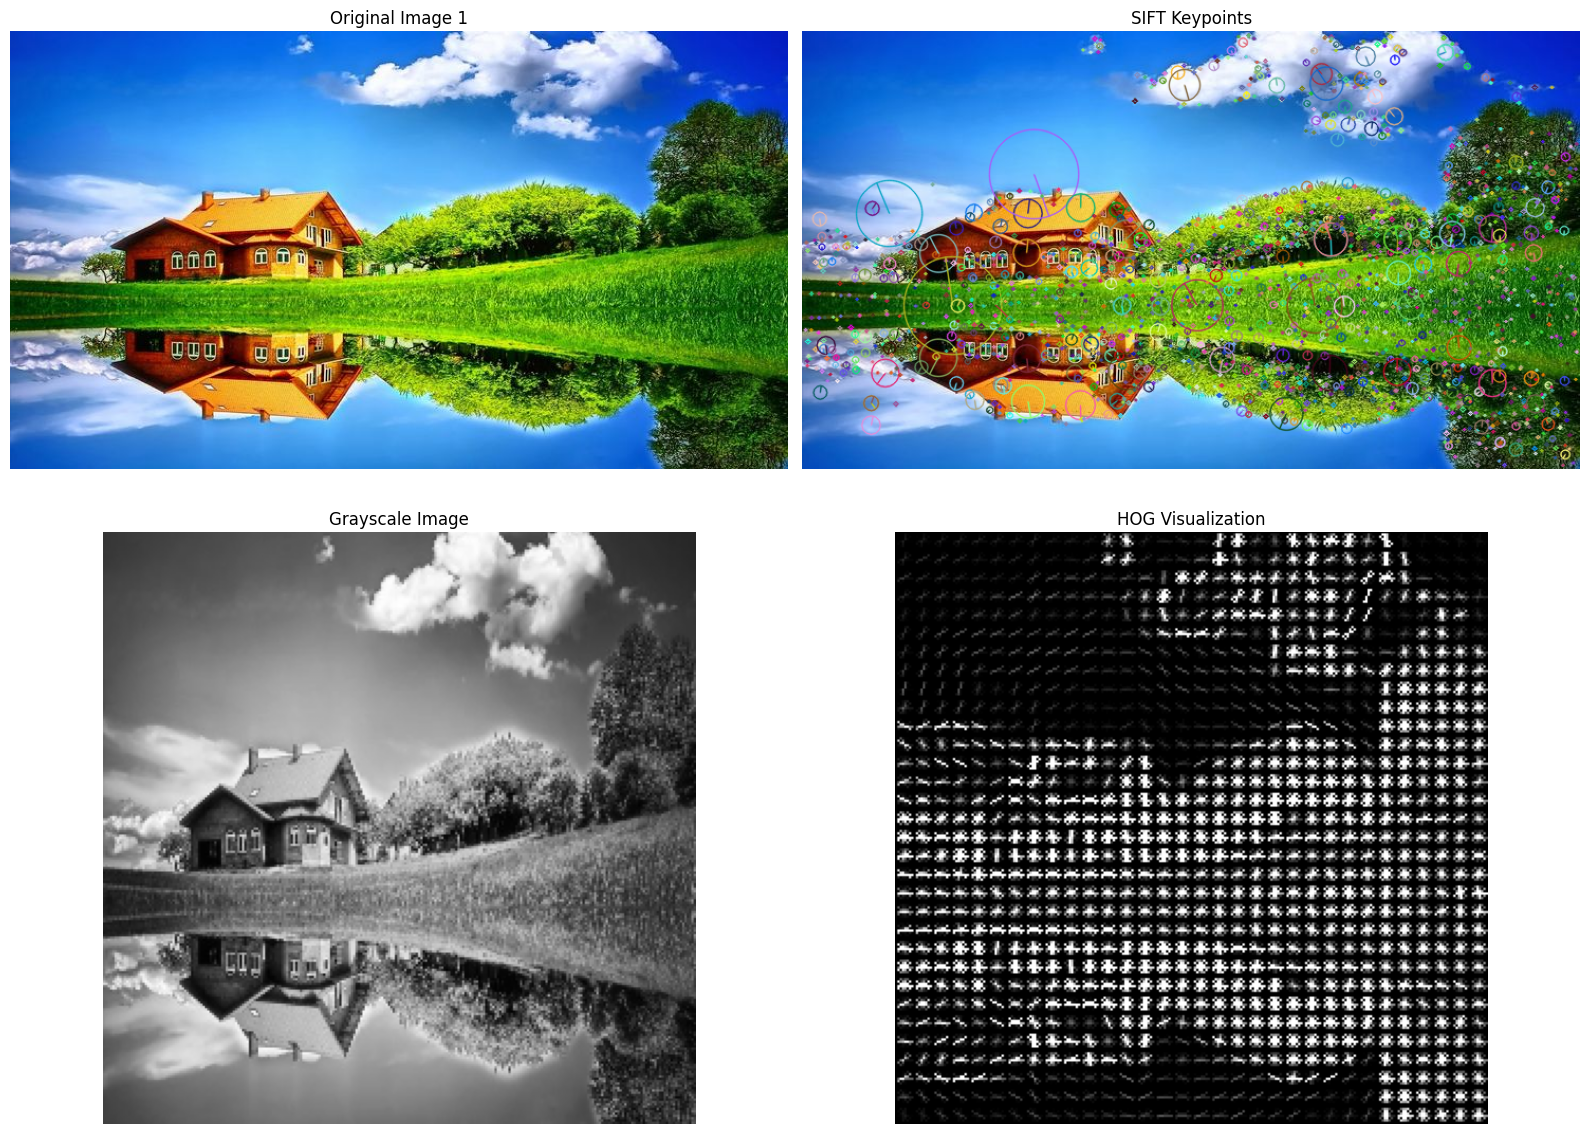

In [ ]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
plt.imshow(img1_rgb)
plt.title("Original Image 1")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sift_img1)
plt.title("SIFT Keypoints")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(gray1_resized, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(hog_image1, cmap="gray")
plt.title("HOG Visualization")
plt.axis("off")

plt.tight_layout()
plt.show()